In [2]:
!pip install ultralytics pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.9 MB/s eta 0:00:00


In [3]:
from google.colab import drive, files
from ultralytics import YOLO
import ultralytics.engine.trainer as trainer_module
import torch
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt

drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/KidneyStone1"
DATA_YAML = os.path.join(PROJECT_DIR, "data", "detection.yaml")
PRETRAINED_MODEL = os.path.join(PROJECT_DIR, "yolo26m.pt")

PROJECT_NAME = "kidney_stone_detector_yolo26s"
RUNS_DIR = os.path.join(PROJECT_DIR, "runs")
TRAIN_RUN_DIR = os.path.join(RUNS_DIR, PROJECT_NAME)
WEIGHTS_DIR = os.path.join(TRAIN_RUN_DIR, "weights")

RESULTS_CSV = os.path.join(TRAIN_RUN_DIR, "results.csv")
WEIGHTS_PATH = os.path.join(WEIGHTS_DIR, "last.pt")
BEST_WEIGHTS_PATH = os.path.join(WEIGHTS_DIR, "best.pt")
EVAL_METRICS_FILE = os.path.join(TRAIN_RUN_DIR, "eval_metrics.txt")

EPOCHS = 100
IMG_SIZE = 896
BATCH_SIZE = 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"
WORKERS = 2
SAVE_PERIOD = 10

print("Configuration loaded.")
print("Epochs     :", EPOCHS)
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)
print("Device     :", DEVICE)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Mounted at /content/drive
Configuration loaded.
Epochs     : 100
Image size : 896
Batch size : 8
Device     : 0


In [4]:
if not os.path.exists(PRETRAINED_MODEL):
    model = YOLO("yolo26m.pt")
    shutil.copy("yolo26m.pt", PRETRAINED_MODEL)

print("YOLO26m weights:", PRETRAINED_MODEL)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))

YOLO26m weights: /content/drive/MyDrive/KidneyStone1/yolo26m.pt
CUDA available : True
GPU            : Tesla T4


In [5]:
print("PROJECT :", os.path.exists(PROJECT_DIR))
print("YAML    :", os.path.exists(DATA_YAML))
print("MODEL   :", os.path.exists(PRETRAINED_MODEL))
print("RUN DIR :", TRAIN_RUN_DIR)

print("\n--- DETECTION YAML ---")
with open(DATA_YAML, "r") as f:
    print(f.read())

PROJECT : True
YAML    : True
MODEL   : True
RUN DIR : /content/drive/MyDrive/KidneyStone1/runs/kidney_stone_detector_yolo26s

--- DETECTION YAML ---
train: train/images
val: valid/images
test: test/images
nc: 1
names: ['stone']


In [5]:
model = YOLO(PRETRAINED_MODEL)
print("YOLO26m model loaded successfully.")

YOLO26m model loaded successfully.


In [6]:
_original_strip_optimizer = trainer_module.strip_optimizer

def keep_full_checkpoint(file, updates=None):
    ckpt = torch.load(file, map_location="cpu", weights_only=False)
    if updates:
        ckpt.update(updates)
        torch.save(ckpt, file)
    return ckpt

trainer_module.strip_optimizer = keep_full_checkpoint


def train_model():
    print("1 = NEW TRAINING")
    print("2 = RESUME FROM last.pt")
    choice = input("Choose: ").strip()

    if choice == "1":
        train_model = YOLO(PRETRAINED_MODEL)
        train_model.train(
            data=DATA_YAML,
            epochs=EPOCHS,
            imgsz=IMG_SIZE,
            batch=BATCH_SIZE,
            device=DEVICE,
            workers=WORKERS,
            project=RUNS_DIR,
            name=PROJECT_NAME,
            pretrained=True,
            save=True,
            save_period=SAVE_PERIOD,
            resume=False,
            exist_ok=True,
            patience=20,
            val=True,
            plots=True,
            seed=0
        )

    elif choice == "2":
        if not os.path.exists(WEIGHTS_PATH):
            print("last.pt not found.")
            return

        ckpt = torch.load(
            WEIGHTS_PATH,
            map_location="cpu",
            weights_only=False
        )

        if ckpt.get("epoch") is None or ckpt.get("optimizer") is None:
            print("last.pt is not a resumable checkpoint.")
            print("Use a saved epoch checkpoint once to recover.")
            return

        if "train_args" not in ckpt:
            print("train_args not found in last.pt.")
            return

        saved_epoch = int(ckpt["epoch"])
        old_epochs = ckpt["train_args"].get("epochs", None)

        if EPOCHS <= saved_epoch + 1:
            print(f"EPOCHS must be greater than {saved_epoch + 1}.")
            return

        shutil.copy2(
            WEIGHTS_PATH,
            os.path.join(WEIGHTS_DIR, "last_before_resume_backup.pt")
        )

        ckpt["train_args"]["epochs"] = EPOCHS
        torch.save(ckpt, WEIGHTS_PATH)

        print(f"Previous total epochs : {old_epochs}")
        print(f"New total epochs      : {EPOCHS}")
        print(f"Resuming from epoch   : {saved_epoch + 1}")

        train_model = YOLO(WEIGHTS_PATH)
        train_model.train(
            data=DATA_YAML,
            epochs=EPOCHS,
            imgsz=IMG_SIZE,
            batch=BATCH_SIZE,
            device=DEVICE,
            workers=WORKERS,
            project=RUNS_DIR,
            name=PROJECT_NAME,
            save=True,
            save_period=SAVE_PERIOD,
            resume=True,
            exist_ok=True,
            patience=20,
            val=True,
            plots=True,
            seed=0
        )

    else:
        print("Invalid choice.")


train_model()

trainer_module.strip_optimizer = _original_strip_optimizer

1 = NEW TRAINING
2 = RESUME FROM last.pt
Choose: 2
Previous total epochs : 100
New total epochs      : 100
Resuming from epoch   : 47
Ultralytics 8.4.139 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/KidneyStone1/data/detection.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=896, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, l

In [6]:
if os.path.exists(RESULTS_CSV):
    df = pd.read_csv(RESULTS_CSV)
    df.columns = df.columns.str.strip()
    last = df.iloc[-1]

    print("========== TRAINING RESULTS ==========")
    print(f"Epoch       : {int(last['epoch'])}")
    print(f"Precision   : {last['metrics/precision(B)']:.4f}")
    print(f"Recall      : {last['metrics/recall(B)']:.4f}")
    print(f"mAP@0.50    : {last['metrics/mAP50(B)']:.4f}")
    print(f"mAP@0.50:95 : {last['metrics/mAP50-95(B)']:.4f}")
else:
    print("results.csv not found.")

========== TRAINING RESULTS ==========
Epoch       : 82
Precision   : 0.8037
Recall      : 0.7385
mAP@0.50    : 0.7886
mAP@0.50:95 : 0.3093


In [7]:
model = YOLO(BEST_WEIGHTS_PATH)

metrics = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    plots=True
)

precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map50_95 = metrics.box.map

print("========== TEST RESULTS ==========")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"mAP@0.50        : {map50:.4f}")
print(f"mAP@0.50:0.95   : {map50_95:.4f}")

with open(EVAL_METRICS_FILE, "w") as f:
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall    : {recall:.4f}\n")
    f.write(f"mAP@0.50  : {map50:.4f}\n")
    f.write(f"mAP@0.50:0.95 : {map50_95:.4f}\n")

Ultralytics 8.4.139 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 68.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.8±2.7 ms, read: 2.0±4.3 MB/s, size: 16.3 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/KidneyStone1/data/test/labels.cache... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123 18.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.1it/s 7.6s
                   all        123        224      0.796      0.719      0.777      0.344
Speed: 4.3ms preprocess, 38.7ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val
========== TEST RESULTS ==========
Precision       : 0.7964
Recall          : 0.7188
mAP@0.50        

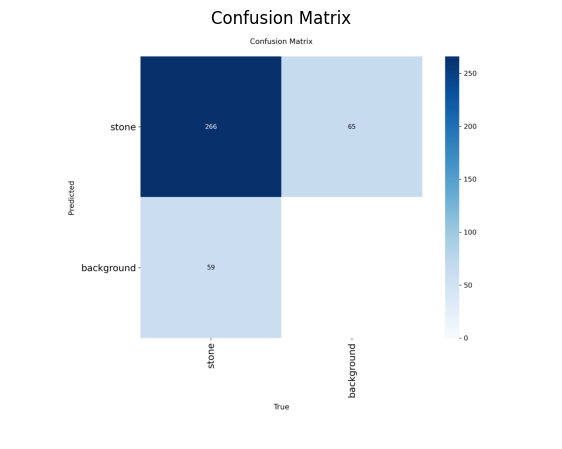

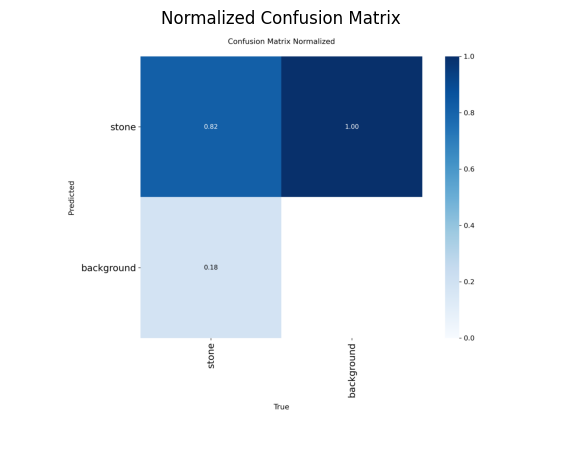

In [8]:
cm = os.path.join(TRAIN_RUN_DIR, "confusion_matrix.png")
cm_norm = os.path.join(TRAIN_RUN_DIR, "confusion_matrix_normalized.png")

for path, title in [
    (cm, "Confusion Matrix"),
    (cm_norm, "Normalized Confusion Matrix")
]:
    if os.path.exists(path):
        plt.figure(figsize=(7, 7))
        plt.imshow(plt.imread(path))
        plt.axis("off")
        plt.title(title)
        plt.show()

Saving P150_RA_M_S_I13.jpg to P150_RA_M_S_I13.jpg

image 1/1 /content/P150_RA_M_S_I13.jpg: 704x896 1 stone, 51.9ms
Speed: 4.5ms preprocess, 51.9ms inference, 1.0ms postprocess per image at shape (1, 3, 704, 896)


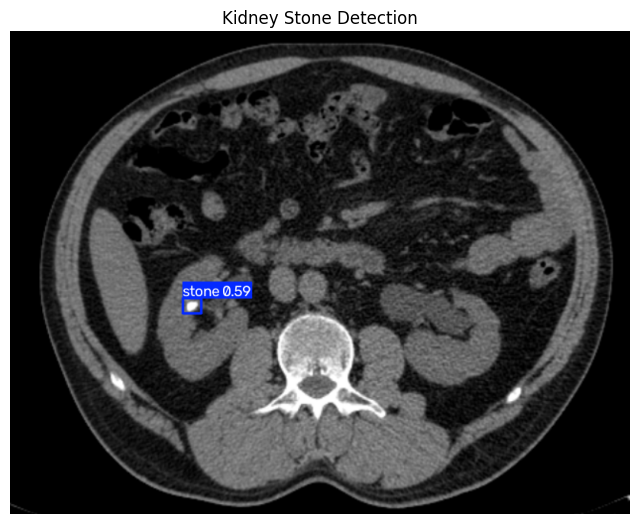

Total stones detected: 1
Detection 1: Confidence=59.17%, Box=(226.5, 349.3) → (250.7, 369.6)


In [9]:
uploaded = files.upload()

if uploaded:
    image_path = next(iter(uploaded))

    model = YOLO(BEST_WEIGHTS_PATH)

    results = model.predict(
        source=image_path,
        imgsz=IMG_SIZE,
        device=DEVICE,
        conf=0.25,
        save=False,
        verbose=True
    )

    res = results[0]
    annotated = res.plot()

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated[..., ::-1])
    plt.axis("off")
    plt.title("Kidney Stone Detection")
    plt.show()

    if res.boxes is None or len(res.boxes) == 0:
        print("No kidney stone detected.")
    else:
        confs = res.boxes.conf.cpu().numpy()
        boxes = res.boxes.xyxy.cpu().numpy()

        print(f"Total stones detected: {len(confs)}")

        for i, (conf, box) in enumerate(zip(confs, boxes), 1):
            x1, y1, x2, y2 = box
            print(
                f"Detection {i}: "
                f"Confidence={conf:.2%}, "
                f"Box=({x1:.1f}, {y1:.1f}) → ({x2:.1f}, {y2:.1f})"
            )